# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4095s 24us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

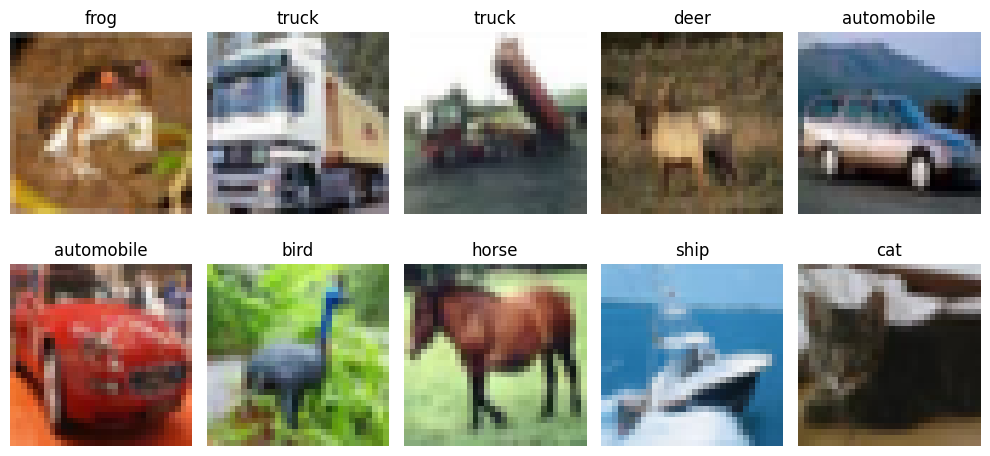

In [ ]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [ ]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [ ]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.2714 - loss: 1.9917 - val_accuracy: 0.3304 - val_loss: 1.8901
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.3173 - loss: 1.8642 - val_accuracy: 0.3614 - val_loss: 1.7798
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.3359 - loss: 1.8156 - val_accuracy: 0.3784 - val_loss: 1.7453
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.3496 - loss: 1.7810 - val_accuracy: 0.3952 - val_loss: 1.7233
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.3548 - loss: 1.7671 - val_accuracy: 0.3974 - val_loss: 1.7045
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.3678 - loss: 1.7375 - val_accuracy: 0.4018 - val_loss: 1.7032
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.3724 - loss: 1.7202 - val_accuracy: 0.4010 - val_loss: 1.6778
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.3784 - loss: 1.7062 - 

In [ ]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4027 - loss: 1.6909
ANN Test Accuracy: 0.4027000069618225


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [ ]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 47s 65ms/step - accuracy: 0.4729 - loss: 1.4777 - val_accuracy: 0.4788 - val_loss: 1.4879
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 45s 64ms/step - accuracy: 0.6030 - loss: 1.1257 - val_accuracy: 0.5610 - val_loss: 1.2371
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 45s 64ms/step - accuracy: 0.6682 - loss: 0.9517 - val_accuracy: 0.6348 - val_loss: 1.0244
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 64ms/step - accuracy: 0.7112 - loss: 0.8344 - val_accuracy: 0.6910 - val_loss: 0.8830
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 64ms/step - accuracy: 0.7447 - loss: 0.7386 - val_accuracy: 0.7090 - val_loss: 0.8370
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 45s 64ms/step - accuracy: 0.7678 - loss: 0.6585 - val_accuracy: 0.7310 - val_loss: 0.8118
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 65ms/step - accuracy: 0.7923 - loss: 0.5949 - val_accuracy: 0.7126 - val_loss: 0.8272
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 64ms/step - accuracy: 0.8129 - loss: 0.5306 - 

In [ ]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.7133 - loss: 0.9294
CNN Test Accuracy: 0.7132999897003174


## 📈 Compare Learning Curves

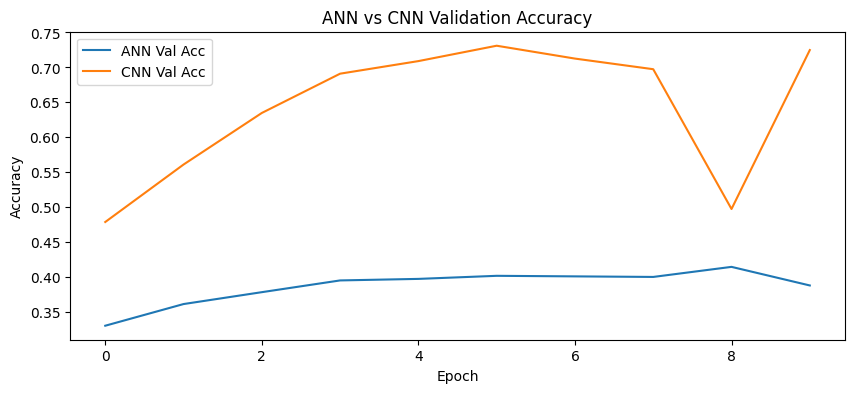

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
# aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

# 📊 Final Comparison Table

In [ ]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4027
1,CNN,0.7133


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

# Completed Tasks
Below, each of the 5 beginner tasks from the previous section is actually implemented and run, so results can be compared directly against the original ANN and CNN models.

## Task 1: Increase ANN layers
Adding two more Dense layers to the original ANN to see if extra depth helps a plain (non-convolutional) network.

In [ ]:
ann_model_v2 = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model_v2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_v2_history = ann_model_v2.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.2608 - loss: 1.9958 - val_accuracy: 0.3290 - val_loss: 1.8448
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 19ms/step - accuracy: 0.3242 - loss: 1.8533 - val_accuracy: 0.3588 - val_loss: 1.7638
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.3454 - loss: 1.7969 - val_accuracy: 0.3798 - val_loss: 1.7434
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.3620 - loss: 1.7658 - val_accuracy: 0.3924 - val_loss: 1.7265
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.3677 - loss: 1.7388 - val_accuracy: 0.4092 - val_loss: 1.6862
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.3793 - loss: 1.7100 - val_accuracy: 0.4054 - val_loss: 1.6553
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 18ms/step - accuracy: 0.3883 - loss: 1.6881 - val_accuracy: 0.3994 - val_loss: 1.6777
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.3948 - loss: 1.6722 - 

In [ ]:
ann_v2_test_loss, ann_v2_test_acc = ann_model_v2.evaluate(x_test_flat, y_test)
print("Deeper ANN Test Accuracy:", ann_v2_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4322 - loss: 1.6124
Deeper ANN Test Accuracy: 0.43220001459121704


## Task 2: Change CNN filters from 32 → 64 → 128
The CNN built in Part 2 already uses this exact filter progression (Conv2D(32) → Conv2D(64) → Conv2D(128)), so cnn_model above is the answer to this task. To make the comparison clearer, here's a version that goes even wider (64 → 128 → 256) to see whether more filters keep helping.

In [ ]:
cnn_model_wide = models.Sequential([
    layers.Conv2D(64, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(256, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model_wide.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_wide_history = cnn_model_wide.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 141s 198ms/step - accuracy: 0.4465 - loss: 1.5386 - val_accuracy: 0.5142 - val_loss: 1.3730
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 137s 194ms/step - accuracy: 0.6078 - loss: 1.1310 - val_accuracy: 0.6298 - val_loss: 1.0743
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 152s 209ms/step - accuracy: 0.6740 - loss: 0.9392 - val_accuracy: 0.6388 - val_loss: 1.0407
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 144s 205ms/step - accuracy: 0.7168 - loss: 0.8137 - val_accuracy: 0.6596 - val_loss: 0.9898
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 212s 220ms/step - accuracy: 0.7562 - loss: 0.6975 - val_accuracy: 0.7190 - val_loss: 0.8206
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 202s 220ms/step - accuracy: 0.7888 - loss: 0.6054 - val_accuracy: 0.7090 - val_loss: 0.8590
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 149s 212ms/step - accuracy: 0.8181 - loss: 0.5257 - val_accuracy: 0.6948 - val_loss: 0.9464
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 195s 201ms/step - accuracy: 0.8431 -

In [ ]:
cnn_wide_test_loss, cnn_wide_test_acc = cnn_model_wide.evaluate(x_test_norm, y_test)
print("Wide-filter CNN (64-128-256) Test Accuracy:", cnn_wide_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.7265 - loss: 0.9657
Wide-filter CNN (64-128-256) Test Accuracy: 0.7264999747276306


## Task 3: Increase epochs to 20
Same CNN architecture as Part 2, trained for 20 epochs instead of 10.

In [ ]:
cnn_model_20 = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model_20.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_20_history = cnn_model_20.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 48s 67ms/step - accuracy: 0.4679 - loss: 1.4964 - val_accuracy: 0.5682 - val_loss: 1.2204
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 47s 67ms/step - accuracy: 0.6069 - loss: 1.1252 - val_accuracy: 0.5658 - val_loss: 1.3223
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 67ms/step - accuracy: 0.6691 - loss: 0.9497 - val_accuracy: 0.5932 - val_loss: 1.1810
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 47s 67ms/step - accuracy: 0.7128 - loss: 0.8262 - val_accuracy: 0.6794 - val_loss: 0.9175
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 69ms/step - accuracy: 0.7448 - loss: 0.7255 - val_accuracy: 0.6842 - val_loss: 0.9429
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 48s 68ms/step - accuracy: 0.7723 - loss: 0.6452 - val_accuracy: 0.6744 - val_loss: 1.0222
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 47s 66ms/step - accuracy: 0.7980 - loss: 0.5752 - val_accuracy: 0.7438 - val_loss: 0.7928
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 84s 69ms/step - accuracy: 0.8195 - loss: 0.5103 - 

In [ ]:
cnn_20_test_loss, cnn_20_test_acc = cnn_model_20.evaluate(x_test_norm, y_test)
print("CNN (20 epochs) Test Accuracy:", cnn_20_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7029 - loss: 1.3628
CNN (20 epochs) Test Accuracy: 0.7028999924659729


## Task 4: Add EarlyStopping
Same CNN architecture, trained for up to 20 epochs, but `EarlyStopping` monitors validation loss and stops training once it stops improving (restoring the best weights seen).

In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

cnn_model_es = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model_es.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_es_history = cnn_model_es.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 48s 66ms/step - accuracy: 0.4700 - loss: 1.4878 - val_accuracy: 0.5458 - val_loss: 1.2915
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 67ms/step - accuracy: 0.6123 - loss: 1.1148 - val_accuracy: 0.6362 - val_loss: 1.0322
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 65ms/step - accuracy: 0.6723 - loss: 0.9454 - val_accuracy: 0.6362 - val_loss: 1.0397
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 65ms/step - accuracy: 0.7154 - loss: 0.8219 - val_accuracy: 0.6828 - val_loss: 0.9324
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 46s 66ms/step - accuracy: 0.7476 - loss: 0.7254 - val_accuracy: 0.6930 - val_loss: 0.9081
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 48s 67ms/step - accuracy: 0.7716 - loss: 0.6520 - val_accuracy: 0.7150 - val_loss: 0.8376
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 46s 65ms/step - accuracy: 0.7975 - loss: 0.5795 - val_accuracy: 0.7430 - val_loss: 0.7958
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 66ms/step - accuracy: 0.8197 - loss: 0.5141 - 

In [ ]:
cnn_es_test_loss, cnn_es_test_acc = cnn_model_es.evaluate(x_test_norm, y_test)
print("CNN with EarlyStopping Test Accuracy:", cnn_es_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.7300 - loss: 0.8205
CNN with EarlyStopping Test Accuracy: 0.7300000190734863


## Task 5: Add data augmentation training
Actually running the aug_cnn_model defined earlier (RandomFlip + RandomRotation + RandomZoom) instead of leaving the .fit() call commented out.

In [ ]:
aug_history = aug_cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 36s 51ms/step - accuracy: 0.5781 - loss: 1.2016 - val_accuracy: 0.6418 - val_loss: 1.0048
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 50ms/step - accuracy: 0.5816 - loss: 1.1835 - val_accuracy: 0.6492 - val_loss: 0.9760
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 50ms/step - accuracy: 0.5910 - loss: 1.1688 - val_accuracy: 0.6444 - val_loss: 1.0343
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 35s 50ms/step - accuracy: 0.5950 - loss: 1.1577 - val_accuracy: 0.6584 - val_loss: 0.9690
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 49ms/step - accuracy: 0.5972 - loss: 1.1510 - val_accuracy: 0.6600 - val_loss: 0.9581
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 49ms/step - accuracy: 0.6016 - loss: 1.1337 - val_accuracy: 0.6520 - val_loss: 1.0064
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 35s 50ms/step - accuracy: 0.6033 - loss: 1.1289 - val_accuracy: 0.6540 - val_loss: 0.9963
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 50ms/step - accuracy: 0.6082 - loss: 1.1134 - 

In [ ]:
aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(x_test_norm, y_test)
print("Augmented CNN Test Accuracy:", aug_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6678 - loss: 0.9432
Augmented CNN Test Accuracy: 0.6678000092506409


## 📈 Validation Accuracy: All Models Together

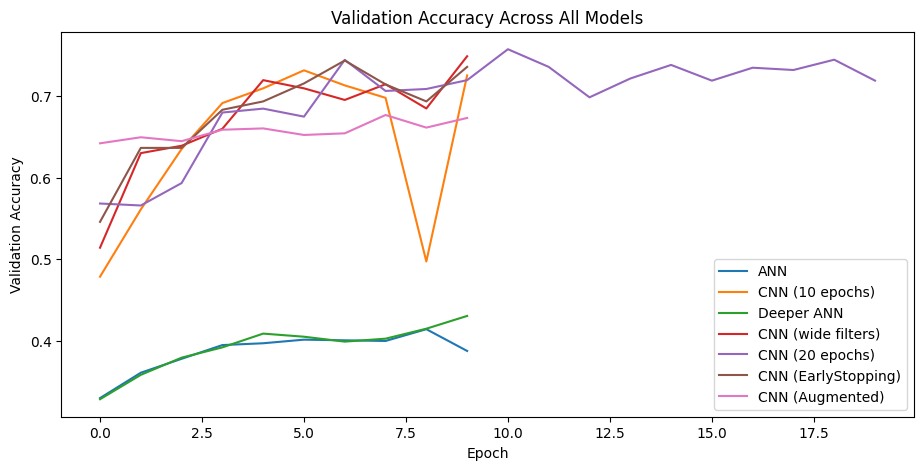

In [ ]:
plt.figure(figsize=(11,5))
plt.plot(ann_history.history['val_accuracy'], label='ANN')
plt.plot(cnn_history.history['val_accuracy'], label='CNN (10 epochs)')
plt.plot(ann_v2_history.history['val_accuracy'], label='Deeper ANN')
plt.plot(cnn_wide_history.history['val_accuracy'], label='CNN (wide filters)')
plt.plot(cnn_20_history.history['val_accuracy'], label='CNN (20 epochs)')
plt.plot(cnn_es_history.history['val_accuracy'], label='CNN (EarlyStopping)')
plt.plot(aug_history.history['val_accuracy'], label='CNN (Augmented)')
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Across All Models")
plt.legend()
plt.show()

##  Updated Comparison Table: All Model Variants

In [ ]:
comparison_full = pd.DataFrame({
    "Model": [
        "ANN", "CNN", "Deeper ANN", "CNN (wide filters)",
        "CNN (20 epochs)", "CNN (EarlyStopping)", "CNN (Augmented)"
    ],
    "Test Accuracy": [
        ann_test_acc, cnn_test_acc, ann_v2_test_acc, cnn_wide_test_acc,
        cnn_20_test_acc, cnn_es_test_acc, aug_test_acc
    ]
})
comparison_full

,Model,Test Accuracy
0,ANN,0.4027
1,CNN,0.7133
2,Deeper ANN,0.4322
3,CNN (wide filters),0.7265
4,CNN (20 epochs),0.7029
5,CNN (EarlyStopping),0.7300
6,CNN (Augmented),0.6678


##  Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**